# Processing 2d-3d dataset
### Matteo Calviello

Working on getting connected to hugging face and getting approval to use the dataset as it is gated.

In [3]:
from huggingface_hub import hf_hub_download, login
import os
import zipfile
import numpy as np
import trimesh
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download, login
from glob import glob
import random
from IPython.display import display, Image
import ipywidgets as widgets

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import resnet18, ResNet18_Weights

In [ ]:
# Replace with your actual token
login("add you HF token here")

In [ ]:
def initialize_folders(categories):
    # Creates the nested directory structure.
    paths = ["../../data/ShapeNet/3d", "../../data/ShapeNet/2d"]
    for base in paths:
        for cat in categories:
            os.makedirs(os.path.join(base, cat), exist_ok=True)
    print("[*] Directory structure initialized.")

def download_shapenet_category(repo_id, category_id):
    # Downloads a category ZIP and extracts a specific number of models.
    print(f"[*] Accessing Hugging Face for Category: {category_id}")
    
    # Download the ZIP from the gated repo
    zip_path = hf_hub_download(
        repo_id=repo_id, 
        filename=f"{category_id}.zip", 
        repo_type="dataset"
    )
    
    target_dir = os.path.join("../../data/ShapeNet/3d", category_id)
    
    print(f"[*] Extracting models to {target_dir}...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        # Get all model files in the zip
        all_files = zip_ref.namelist()
        obj_files = [f for f in all_files if f.endswith('model_normalized.obj')]
        
        # Limit extraction so we don't fill up the hard drive during testing
        to_extract = obj_files  # Extract only first 50 models for testing
        
        for file in to_extract:
            # We extract into our specific data folder
            zip_ref.extract(file, target_dir)
            
    print(f"[*] Successfully downloaded and extracted {len(to_extract)} models.")

### Doanload dataset, limit right now is 50 samples per class but can be changed to get them all

In [16]:
MY_CATEGORIES = ["02691156"] #, "02828884", "02958343", "03001627", "03636649", "04256520", "04379243", "04530566", "03513137"] 
REPO = "ShapeNet/ShapeNetCore"

initialize_folders(MY_CATEGORIES)

for cat_id in MY_CATEGORIES:
    download_shapenet_category(REPO, cat_id)

[*] Directory structure initialized.
[*] Accessing Hugging Face for Category: 02691156
[*] Extracting models to ../data/ShapeNet/3d/02691156...
[*] Successfully downloaded and extracted 4045 models.


In [ ]:
BASE_PATH = "../../data/ShapeNet/3d"
MY_CATEGORIES = ["02691156"]
category_names = {
    "02691156": "Airplane", "02828884": "Bench", "02958343": "Car", 
    "03001627": "Chair", "03636649": "Lamp", "04256520": "Sofa", 
    "04379243": "Table", "04530566": "Watercraft", "03513137": "Helmet"
}

In [4]:
print(f"{'Category':<15} | {'ID':<10} | {'Count':<6}")
print("-" * 35)
    
for cat_id in MY_CATEGORIES:
    path = os.path.join(BASE_PATH, cat_id)
        
    # Look for model_normalized.obj files recursively
    models = glob(os.path.join(path, "**", "model_normalized.obj"), recursive=True)
    count = len(models)
        
    name = category_names.get(cat_id, "Unknown")
    print(f"{name:<15} | {cat_id:<10} | {count:<6}")

Category        | ID         | Count 
-----------------------------------
Airplane        | 02691156   | 4045  


### Print sample of each class to check what they look like

In [5]:
viewers = []

for cat_id in MY_CATEGORIES:
    path = os.path.join(BASE_PATH, cat_id)
    models = glob(os.path.join(path, "**", "model_normalized.obj"), recursive=True)
    
    if models:
        # Load a random model
        mesh = trimesh.load(random.choice(models))
        scene = mesh.scene() if not isinstance(mesh, trimesh.Scene) else mesh
        
        # Increased width to 600px for a better vertical view
        out = widgets.Output(layout={
            'border': '2px solid #444', 
            'width': '600px', 
            'height': '400px',
            'margin': '10px auto'
        })
        
        with out:
            print(f"--- CATEGORY: {category_names[cat_id].upper()} ---")
            display(scene.show(viewer='jupyter'))
        viewers.append(out)

grid = widgets.GridBox(viewers, layout=widgets.Layout(
    grid_template_columns="repeat(1, 100%)",
    align_items='center'
))

display(grid)

GridBox(children=(Output(layout=Layout(border_bottom='2px solid #444', border_left='2px solid #444', border_ri…

### Get some more randoms per one class to see how they look like

In [6]:
# Configuration
AIRPLANE = "02691156"
path = os.path.join(BASE_PATH, AIRPLANE)
models = glob(os.path.join(path, "**", "model_normalized.obj"), recursive=True)

viewers = []

if len(models) >= 5:
    sample_subset = random.sample(models, 5)
    
    for i, model_path in enumerate(sample_subset):
        mesh = trimesh.load(model_path)
        scene = mesh.scene() if not isinstance(mesh, trimesh.Scene) else mesh
        
        # Create a clean container for each airplane
        out = widgets.Output(layout={
            'border': '2px solid #2196F3', # Blue border for Airplanes
            'width': '600px', 
            'height': '400px',
            'margin': '10px auto'
        })
        
        with out:
            print(f"--- AIRPLANE SAMPLE {i+1} ---")
            print(f"Path: ...{model_path[-50:]}")
            display(scene.show(viewer='jupyter'))
        viewers.append(out)

    grid = widgets.GridBox(viewers, layout=widgets.Layout(
        grid_template_columns="repeat(1, 100%)",
        align_items='center'
    ))

    display(grid)
else:
    print(f"[!] Not enough models found. Found: {len(models)}")

GridBox(children=(Output(layout=Layout(border_bottom='2px solid #2196F3', border_left='2px solid #2196F3', bor…

### testing generation of 2d sketch

In [7]:
def generate_sketch_angled(model_path, num_points=20000):
    # Load and Flatten
    loaded = trimesh.load(model_path)
    mesh = loaded.to_mesh() if isinstance(loaded, trimesh.Scene) else loaded
    
    # Robust Normalization
    center = mesh.center_mass if mesh.volume > 1e-8 else mesh.bounding_box.centroid
    mesh.vertices -= center
    
    # Scale to unit sphere
    max_dist = np.max(np.linalg.norm(mesh.vertices, axis=1))
    if max_dist > 0:
        mesh.vertices /= max_dist

    # 45 degree rotation
    angle_y = np.radians(45)   # Turn to see the side
    angle_x = np.radians(-15)  # Tilt slightly up/down
    
    rot_y = trimesh.transformations.rotation_matrix(angle_y, [0, 1, 0])
    rot_x = trimesh.transformations.rotation_matrix(angle_x, [1, 0, 0])
    
    # Combine and apply transformations
    mesh.apply_transform(trimesh.transformations.concatenate_matrices(rot_y, rot_x))

    # Create sketch by sampling points
    points = mesh.sample(num_points)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(points[:, 0], points[:, 1], s=0.01, c='black', alpha=0.4)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title("Angled 2D Sketch (45° View)")

    out_2d = widgets.Output(layout={'width': '50%', 'border': '1px solid gray'})
    with out_2d:
        display(fig)
        plt.close(fig)

    out_3d = widgets.Output(layout={'width': '50%', 'border': '1px solid gray'})
    with out_3d:
        print("3D Reference (Original Orientation)")
        display(loaded.show(viewer='jupyter'))

    display(widgets.HBox([out_2d, out_3d]))

if models:
    sample = random.choice(models)
    generate_sketch_angled(sample)

### generation of 3 sketeches from different angles

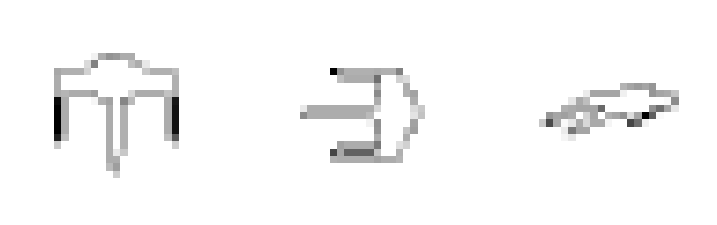

: 

In [ ]:
import trimesh
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from PIL import Image, ImageOps
from skimage import feature
from skimage.morphology import skeletonize
from scipy.ndimage import binary_erosion


def generate_quickdraw_style(model_path):
    # Load and Fix Mesh
    mesh_or_scene = trimesh.load(model_path)
    
    if isinstance(mesh_or_scene, trimesh.Scene):
        mesh = mesh_or_scene.to_geometry()
    else:
        mesh = mesh_or_scene
    
    # Use bounding box centroid instead of center_mass to avoid volume/0 errors
    mesh.vertices -= mesh.bounding_box.centroid
    
    # Robust scaling
    scale = np.max(np.linalg.norm(mesh.vertices, axis=1))
    if scale > 0:
        mesh.vertices /= scale

    views = [
        (np.radians(-90), 0, 0, "Top"),
        (0, np.radians(90), np.radians(45), "Side_Rolled"), # ang_z here will act as our roll
        (np.radians(-20), np.radians(45), 0, "45deg")
    ]
    sketches = []
    for ang_x, ang_y, roll, label in views:
        # Base rotations
        rx = trimesh.transformations.rotation_matrix(ang_x, [1, 0, 0])
        ry = trimesh.transformations.rotation_matrix(ang_y, [0, 1, 0])
        
        # To roll a side view, we rotate around the X-axis after the Y-rotation
        r_roll = trimesh.transformations.rotation_matrix(roll, [1, 0, 0])
        combined = trimesh.transformations.concatenate_matrices(r_roll, ry, rx)
        temp_mesh = mesh.copy().apply_transform(combined)
        
        # reate high-res silhouette (White background, Black points)
        fig, ax = plt.subplots(figsize=(4, 4), dpi=100)
        fig.patch.set_facecolor('white') # Ensure white background
        
        # Project full mesh faces to 2D
        verts_2d = temp_mesh.vertices[:, :2]
        faces = temp_mesh.faces

        tri = Triangulation(verts_2d[:, 0], verts_2d[:, 1], faces)
        ax.tripcolor(tri, np.ones(len(faces)), color='black')
        
        ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
        ax.axis('off')
        
        fig.canvas.draw()
        rgba_buffer = np.asarray(fig.canvas.buffer_rgba())
        plt.close(fig)
        
        # Process Edges
        img_gray = Image.fromarray(rgba_buffer).convert("L")
        img_np = np.array(img_gray)
        
        # Binary silhouette
        binary = img_np < 200

        # Boundary = silhouette - eroded silhouette
        boundary = binary ^ binary_erosion(binary)

        # Thin to single-pixel stroke
        thin = skeletonize(boundary)
        outline_img = Image.fromarray((~thin * 255).astype(np.uint8))

        # Downsample to 28x28
        final_sketch = outline_img.resize((28, 28), Image.Resampling.BOX)
        sketches.append(final_sketch)

    # Visualization
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    for i, s in enumerate(sketches):
        axes[i].imshow(s, cmap='gray')
        axes[i].axis('off')
    plt.show()

if models:
    generate_quickdraw_style(random.choice(models))

### Code to get 2d sketches for all 3d .obj files

In [ ]:
import trimesh
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from PIL import Image
from skimage.morphology import skeletonize
from scipy.ndimage import binary_erosion
import os
from glob import glob
from tqdm import tqdm

def generate_all_sketches_fixed_paths(categories):
    # Define the 3 view configurations: (angle_x, angle_y, roll, suffix)
    view_configs = [
        (np.radians(-90), 0, 0, "top"),
        (0, np.radians(90), np.radians(45), "side"),
        (np.radians(-20), np.radians(45), 0, "45deg")
    ]

    for cat_id in categories:
        src_path = os.path.join("../../data", "ShapeNet", "3d", cat_id, cat_id)
        obj_paths = glob(os.path.join(src_path, "**", "model_normalized.obj"), recursive=True)
        
        dest_category_path = os.path.join("../../data", "ShapeNet", "2d", cat_id)
        os.makedirs(dest_category_path, exist_ok=True)
        
        print(f"[*] Category {cat_id}: Found {len(obj_paths)} models.")
        
        # tqdm progress bar wrapped around the model list
        for i, model_path in enumerate(tqdm(obj_paths, desc=f"Processing {cat_id}")):
            path_parts = model_path.split(os.sep)
            model_id = path_parts[-3] 
            
            # Check if all 3 views already exist
            suffixes = [v[3] for v in view_configs]
            expected_files = [os.path.join(dest_category_path, f"{model_id}_{s}.png") for s in suffixes]
            
            if all(os.path.exists(f) for f in expected_files):
                continue # Skip if fully completed
            
            try:
                # Load and Fix Mesh
                loaded = trimesh.load(model_path)
                mesh = loaded.to_geometry() if isinstance(loaded, trimesh.Scene) else loaded
                
                # Normalize centering and scale
                mesh.vertices -= mesh.bounding_box.centroid
                scale = np.max(np.linalg.norm(mesh.vertices, axis=1))
                if scale > 0: 
                    mesh.vertices /= scale

                # Process each of the 3 views
                for ang_x, ang_y, roll, suffix in view_configs:
                    save_path = os.path.join(dest_category_path, f"{model_id}_{suffix}.png")
                    
                    # Nested check: if individual file exists, don't re-render it
                    if os.path.exists(save_path):
                        continue

                    # Apply Rotations
                    rx = trimesh.transformations.rotation_matrix(ang_x, [1, 0, 0])
                    ry = trimesh.transformations.rotation_matrix(ang_y, [0, 1, 0])
                    r_roll = trimesh.transformations.rotation_matrix(roll, [1, 0, 0])
                    combined = trimesh.transformations.concatenate_matrices(r_roll, ry, rx)
                    
                    temp_mesh = mesh.copy().apply_transform(combined)

                    # Create high-res silhouette
                    fig, ax = plt.subplots(figsize=(4, 4), dpi=100)
                    fig.patch.set_facecolor('white')
                    
                    verts_2d = temp_mesh.vertices[:, :2]
                    faces = temp_mesh.faces
                    tri = Triangulation(verts_2d[:, 0], verts_2d[:, 1], faces)
                    ax.tripcolor(tri, np.ones(len(faces)), color='black')
                    
                    ax.set_xlim(-1.1, 1.1)
                    ax.set_ylim(-1.1, 1.1)
                    ax.axis('off')
                    
                    # Capture to buffer
                    fig.canvas.draw()
                    rgba_buffer = np.asarray(fig.canvas.buffer_rgba())
                    plt.close(fig)
                    
                    # Process Edges
                    img_gray = Image.fromarray(rgba_buffer).convert("L")
                    img_np = np.array(img_gray)
                    
                    binary = img_np < 200 
                    boundary = binary ^ binary_erosion(binary)
                    thin = skeletonize(boundary)
                    
                    # Convert to PIL Image
                    outline_img = Image.fromarray((~thin * 255).astype(np.uint8))
                    
                    # Downsample to 28x28 and Save
                    final_sketch = outline_img.resize((28, 28), Image.Resampling.BOX)
                    final_sketch.save(save_path)

            except Exception as e:
                tqdm.write(f" [!] Error on {model_id}: {e}")

if __name__ == "__main__":
    generate_all_sketches_fixed_paths(['02691156'])

[*] Category 02691156: Found 4045 models.


Processing 02691156: 100%|██████████| 4045/4045 [16:00<00:00,  4.21it/s]  


### Shapnet .onj files are too big and hard to be processed by the model, so we will use .npy files with 2048 points

In [ ]:
def convert_shapenet_to_npy(categories, num_points=2048):
    # Define the new root for point clouds
    npy_root = os.path.join("../../data", "ShapeNet", "npy")
    
    for cat_id in categories:
        src_path = os.path.join("../../data", "ShapeNet", "3d", cat_id, cat_id)
        obj_paths = glob(os.path.join(src_path, "**", "model_normalized.obj"), recursive=True)
        
        dest_cat_path = os.path.join(npy_root, cat_id)
        os.makedirs(dest_cat_path, exist_ok=True)
        
        print(f"[*] Processing {len(obj_paths)} models for category {cat_id}...")

        for i, model_path in enumerate(obj_paths):
            path_parts = model_path.split(os.sep)
            model_id = path_parts[-3]
            
            save_path = os.path.join(dest_cat_path, f"{model_id}.npy")
            
            if os.path.exists(save_path):
                continue

            try:
                # Load and flatten mesh
                loaded = trimesh.load(model_path)
                mesh = loaded.to_mesh() if isinstance(loaded, trimesh.Scene) else loaded
                
                # Sample fixed number of points from surface area
                points, _ = trimesh.sample.sample_surface(mesh, count=num_points)
                
                # Normalize points to unit sphere (matches your sketch normalization)
                points -= np.mean(points, axis=0)
                max_dist = np.max(np.linalg.norm(points, axis=1))
                if max_dist > 0:
                    points /= max_dist
                
                # Save as float32 to match PyTorch expectations
                np.save(save_path, points.astype(np.float32))

                if (i + 1) % 100 == 0:
                    print(f"    Converted {i + 1}/{len(obj_paths)}...")

            except Exception as e:
                print(f" [!] Error on {model_id}: {e}")

# Run for your categories
convert_shapenet_to_npy(MY_CATEGORIES)

[*] Processing 4045 models for category 02691156...
    Converted 100/4045...
    Converted 200/4045...
    Converted 300/4045...
    Converted 400/4045...
    Converted 500/4045...
    Converted 600/4045...
    Converted 700/4045...
    Converted 800/4045...
    Converted 900/4045...
    Converted 1000/4045...
    Converted 1100/4045...
    Converted 1200/4045...
    Converted 1300/4045...
    Converted 1400/4045...
    Converted 1500/4045...
    Converted 1600/4045...
    Converted 1700/4045...
    Converted 1800/4045...
    Converted 1900/4045...
    Converted 2000/4045...
    Converted 2100/4045...
    Converted 2200/4045...
    Converted 2300/4045...
    Converted 2400/4045...
    Converted 2500/4045...
    Converted 2600/4045...
    Converted 2700/4045...
    Converted 2800/4045...
    Converted 2900/4045...
    Converted 3000/4045...
    Converted 3100/4045...
    Converted 3200/4045...
    Converted 3300/4045...
    Converted 3400/4045...
    Converted 3500/4045...
    Converte

Sampled files:
48a9b9c041d377b26012a714b05f25ca.npy
8bb827904cd9acd36c1cd53dbc9f7b8e.npy
e409d714620161c132fa725d7a62a02a.npy
63a2144cfae402149b30aa09067b7eef.npy
d15e3519a61c5bad86442c51e82d8d69.npy


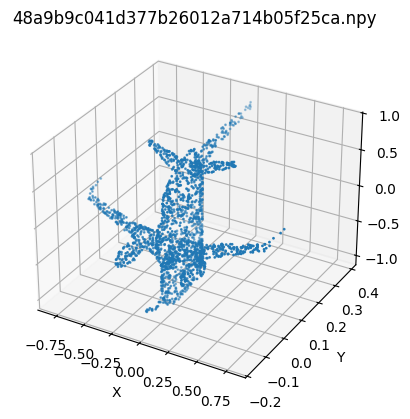

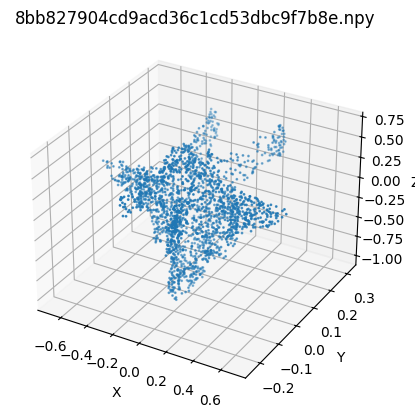

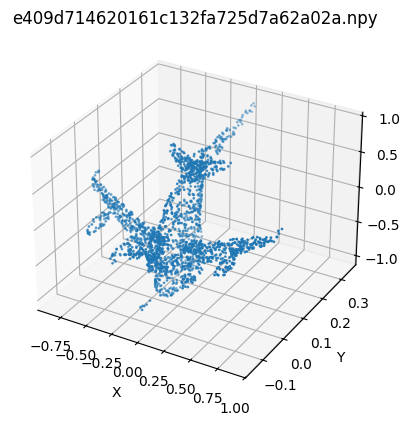

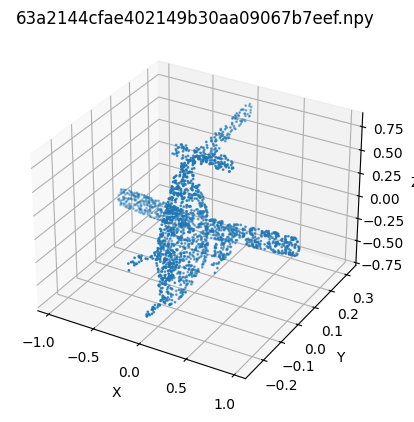

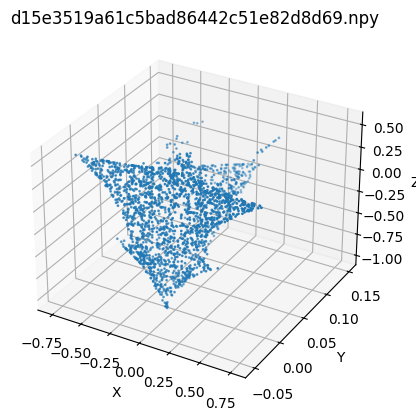

In [7]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

# Path to folder containing .npy files
NPY_DIR = "../../data/ShapeNet/npy/02691156"

# List all .npy files
npy_files = [f for f in os.listdir(NPY_DIR) if f.endswith(".npy")]

# Randomly sample 5 files (or fewer if less exist)
sampled_files = random.sample(npy_files, min(5, len(npy_files)))

print("Sampled files:")
for f in sampled_files:
    print(f)

# Plot each file
for fname in sampled_files:
    data = np.load(os.path.join(NPY_DIR, fname))

    # Assume XYZ are first 3 columns
    xyz = data[:, :3]

    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], s=1)

    ax.set_title(fname)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    plt.show()